In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from ibllib.atlas import AllenAtlas
from brainbox.io.spikeglx import Streamer
from neurodsp.voltage import destripe
from datetime import datetime
from pprint import pprint

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


/usr/local/lib/python3.10/dist-packages/ibllib/atlas/__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '
/usr/local/lib/python3.10/dist-packages/neurodsp/__init__.py:5: FutureWarning: neurodsp has been renamed to ibldsp and the old name will be deprecated on 01-Sep-2024.
  warn(
/usr/local/lib/python3.10/dist-packages/ibllib/atlas/atlas.py:13: DeprecationWarning: ibllib.atlas.atlas.AllenAtlas is deprecated. Use iblatlas.atlas.AllenAtlas instead
  warnings.warn(warning_text, DeprecationWarning)


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:03<00:00,  8.35it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:01<00:00,  2.23it/s]


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [5]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
}


In [6]:
Mat_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt')

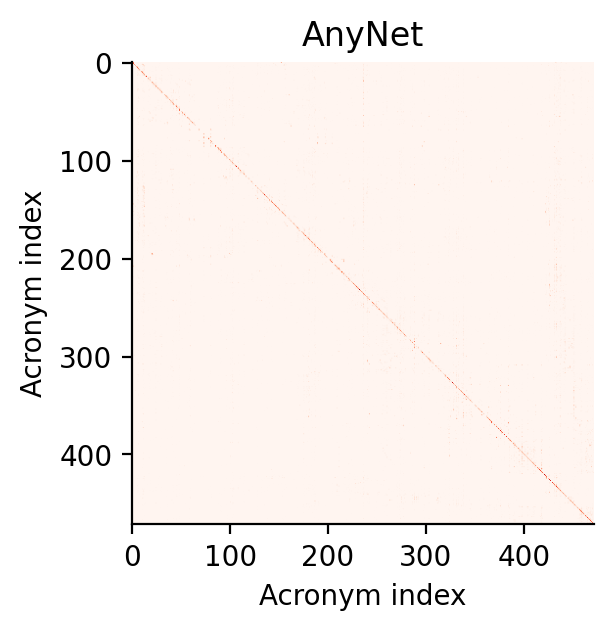

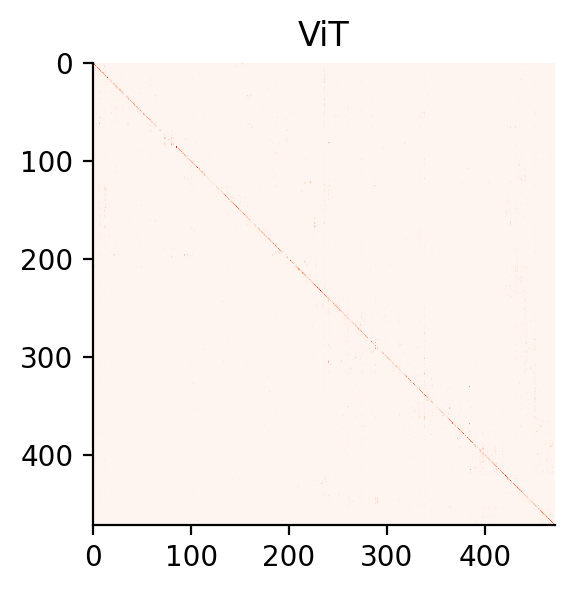

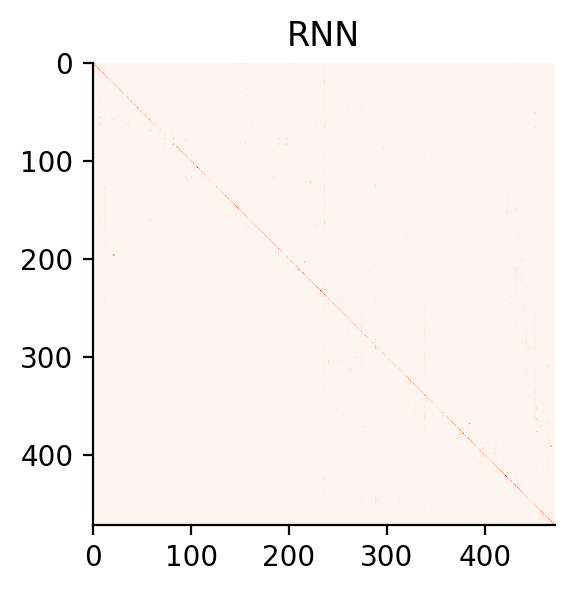

In [9]:
for name_ii, name in enumerate(['AnyNet', 'ViT', 'RNN']):
    plt.figure(figsize=(3, 3), dpi=200)
    plt.imshow(Mat_dict[name], 'Reds')
    sns.despine()
    if name_ii == 0:
        plt.xlabel('Acronym index')
        plt.ylabel('Acronym index')
    plt.title(name)
    plt.show()

In [10]:
!pip install networkx
import networkx as nx

In [11]:
modularity_value_dict = {}
for name in [ 'AnyNet', 'ViT', 'RNN']:
    modularity_value = []
    for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
        G = nx.from_numpy_array(Mat_dict[name].copy())
        c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
        label_acronym = []
        community_label = []
        for c_ii, c0 in enumerate(c):
            for c_index in c0:
                community_label.append(c_ii)
                label_acronym.append(acronym_list[c_index])

        community_label = np.array(community_label)
        print(f'resolution: {resolution}>>>>>>>>>>>', nx.community.modularity(G, c))
        # community_label
        modularity_value.append(nx.community.modularity(G, c))
    modularity_value = np.array(modularity_value)
    modularity_value_dict[name] = modularity_value

resolution: 0.2>>>>>>>>>>> 0.04350889680845049
resolution: 0.4>>>>>>>>>>> 0.35574108457424736
resolution: 0.6>>>>>>>>>>> 0.5165866735957058
resolution: 0.8>>>>>>>>>>> 0.5397727026079717
resolution: 1.0>>>>>>>>>>> 0.5490413709541083
resolution: 1.2>>>>>>>>>>> 0.5477914283167886
resolution: 1.4>>>>>>>>>>> 0.5413834677373004
resolution: 1.6>>>>>>>>>>> 0.5344992343137612
resolution: 1.8>>>>>>>>>>> 0.533051178172249
resolution: 2.0>>>>>>>>>>> 0.5287439691246753
resolution: 0.2>>>>>>>>>>> 0.043627949176549184
resolution: 0.4>>>>>>>>>>> 0.34477253508805505
resolution: 0.6>>>>>>>>>>> 0.5127628310027095
resolution: 0.8>>>>>>>>>>> 0.5440619193035315
resolution: 1.0>>>>>>>>>>> 0.5546289671593724
resolution: 1.2>>>>>>>>>>> 0.5538384500861764
resolution: 1.4>>>>>>>>>>> 0.5483040755066049
resolution: 1.6>>>>>>>>>>> 0.5438113896918942
resolution: 1.8>>>>>>>>>>> 0.5371216872164302
resolution: 2.0>>>>>>>>>>> 0.5350323043931036
resolution: 0.2>>>>>>>>>>> 0.021066063966645274
resolution: 0.4>>>>>>>>>>> 0

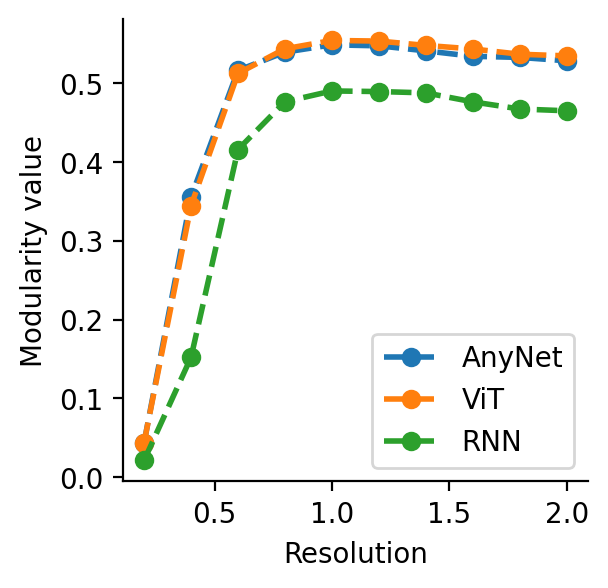

In [12]:
plt.figure(figsize=(3, 3), dpi=200)
for name in [ 'AnyNet', 'ViT', 'RNN']:
    plt.plot([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_value_dict[name], 'o--', linewidth=2, label=name)
plt.ylabel('Modularity value')
plt.xlabel('Resolution')
plt.legend()
sns.despine()
plt.show()

In [13]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [14]:
# @title Clustering number analysis
overlap_repeat_dict = {}
for name in [ 'AnyNet', 'ViT', 'RNN']:
# name = 'AnyNet'
    overlap_repeat = []
    for num in range(0, 10):
        node_ii = np.sort(np.random.choice(len(acronym_list), len(acronym_list)//5, replace=False))
        X1 = np.delete(copy.deepcopy(Mat_dict[name]), node_ii, axis=0)
        X1 = np.delete(X1, node_ii, axis=1)
        X = copy.deepcopy(Mat_dict[name])
        overlap_n = []
        for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
            community_label1, acronym_label1, index1 = modularity_separation(X1, resolution)
            community_label, acronym_label, index = modularity_separation(X, resolution)
            overlap = []
            for i in np.sort(np.unique(community_label1)):
                label1_ind = index1[np.argwhere(community_label1 == i)]
                label_ind = index[np.argwhere(community_label == np.argmax(np.bincount(community_label[label1_ind].flatten())))]
                overlap.append(len(np.intersect1d(label_ind, label1_ind)) / len(label1_ind))
            overlap = np.array(overlap)
            overlap_n.append(overlap.mean())
        overlap_n = np.array(overlap_n)
        overlap_repeat.append(overlap_n)
    overlap_repeat = np.array(overlap_repeat)
    overlap_repeat_dict[name] = overlap_repeat

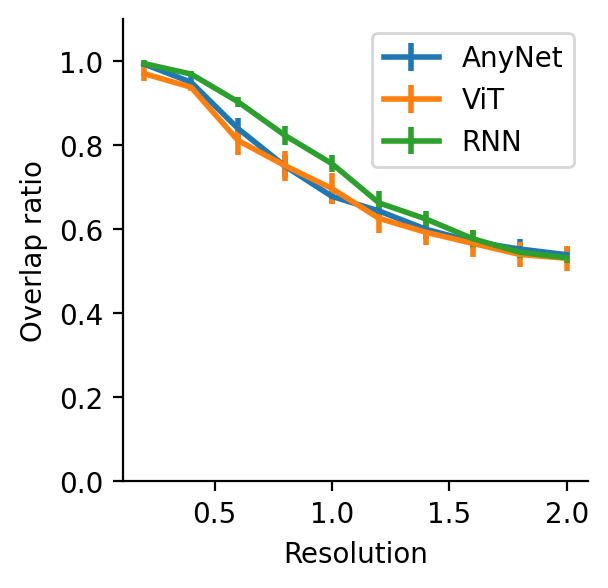

In [16]:
plt.figure(figsize=(3, 3), dpi=200)
for name in [ 'AnyNet', 'ViT', 'RNN']:
    plt.errorbar([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], overlap_repeat_dict[name].mean(axis=0), yerr=overlap_repeat_dict[name].std(axis=0), linewidth=2, label=name)
plt.ylabel('Overlap ratio')
plt.xlabel('Resolution')
plt.ylim([0, 1.1])
plt.legend()
sns.despine()
plt.show()

In [17]:
# @title Clustering number analysis
overlap_repeat_dict_rm = {}
for name in [ 'AnyNet', 'ViT', 'RNN']:
# name = 'AnyNet'
    overlap_repeat = []
    for num in range(0, 10):
        node_ii = np.sort(np.random.choice(len(acronym_list), len(acronym_list)//5, replace=False))
        X1 = np.delete(copy.deepcopy(Mat_dict[name]), node_ii, axis=0)
        X1 = np.delete(X1, node_ii, axis=1)
        X = copy.deepcopy(Mat_dict[name])
        overlap_n = []
        for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
            community_label1, acronym_label1, index1 = modularity_separation(X1, resolution)
            community_label, acronym_label, index = modularity_separation(X, resolution)
            overlap = []
            for i in np.sort(np.unique(community_label1)):
                if len(np.argwhere(community_label == i).flatten()) < 2:
                    continue
                label1_ind = index1[np.argwhere(community_label1 == i)]
                label_ind = index[np.argwhere(community_label == np.argmax(np.bincount(community_label[label1_ind].flatten())))]
                overlap.append(len(np.intersect1d(label_ind, label1_ind)) / len(label1_ind))
            overlap = np.array(overlap)
            overlap_n.append(overlap.mean())
        overlap_n = np.array(overlap_n)
        overlap_repeat.append(overlap_n)
    overlap_repeat = np.array(overlap_repeat)
    overlap_repeat_dict_rm[name] = overlap_repeat

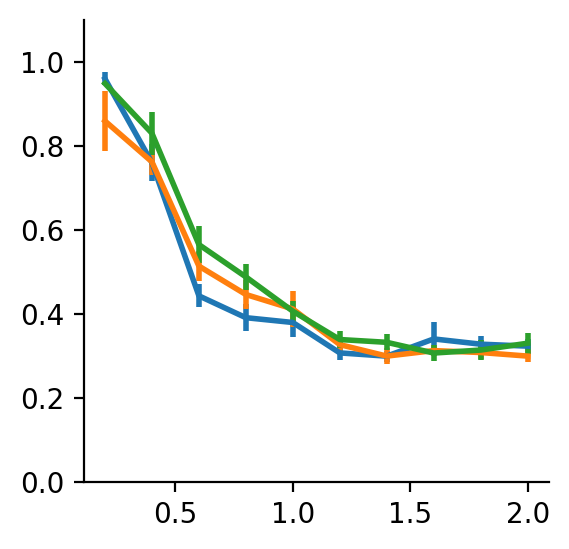

In [20]:
plt.figure(figsize=(3, 3), dpi=200)
for name in [ 'AnyNet', 'ViT', 'RNN']:
    plt.errorbar([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], overlap_repeat_dict_rm[name].mean(axis=0), yerr=overlap_repeat_dict_rm[name].std(axis=0), linewidth=2, label=name)
# plt.ylabel('Overlap ratio (rm)')
# plt.xlabel('Resolution')
plt.ylim([0, 1.1])
# plt.legend()
sns.despine()
plt.show()

In [21]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [22]:
cmap_selec = mpl.cm.get_cmap('tab20')

<ipython-input-22-bbe78ac034aa>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_selec = mpl.cm.get_cmap('tab20')


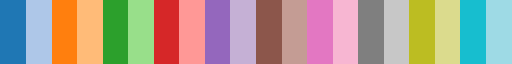

In [23]:
cmap_selec

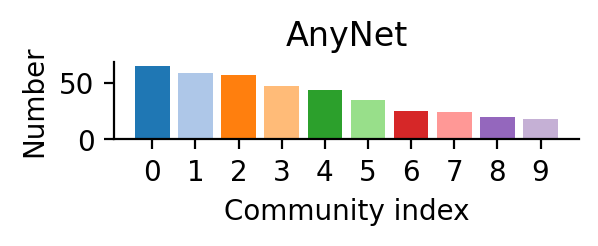

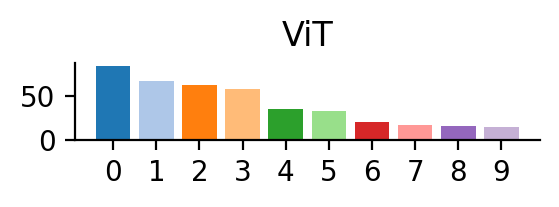

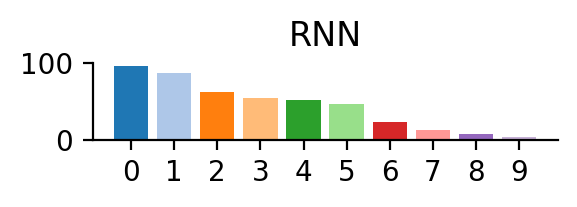

1.0


In [27]:
resolution = 1.0
for name in [ 'AnyNet', 'ViT', 'RNN']:
    X = copy.deepcopy(Mat_dict[name])
    community_label, acronym_label, index = modularity_separation(X, resolution)

    # community_label_hist_mark = [community_ii for community_ii in np.unique(community_label)]
    # community_label_hist = [len(np.argwhere(community_label == community_ii).flatten()) for community_ii in np.unique(community_label)]

    plt.figure(figsize=(3, 0.5), dpi=200)
    for community_index, community_ii in enumerate(np.unique(community_label)):
        if community_index < 10:
            plt.bar(community_ii, len(np.argwhere(community_label == community_ii).flatten()), color=cmap_selec(community_index))
    sns.despine()
    if name == 'AnyNet':
        plt.xlabel('Community index')
        plt.ylabel('Number')
    plt.xticks(np.arange(0, 10), np.arange(0, 10))
    plt.title(name)
    plt.show()

print(resolution)

In [31]:
name = 'RNN'
X = copy.deepcopy(Mat_dict[name])
resolution = 1.0
community_label, acronym_label, index = modularity_separation(X, resolution)

community_label_selec = community_label[np.argwhere(community_label <= 9).flatten()]
acronym_label_selec = acronym_label[np.argwhere(community_label <= 9).flatten()]

for indice in range(-5000, 0, 500):
    fig, ax = plot_scalar_on_slice(acronym_label_selec, community_label_selec, coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'sagittal indice: {indice}')

for indice in range(-5000, 0, 500):
    fig, ax = plot_scalar_on_slice(acronym_label_selec, community_label_selec, coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'horizontal indice: {indice}')

for indice in range(-5000, 0, 500):
    fig, ax = plot_scalar_on_slice(acronym_label_selec, community_label_selec, coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
                                background='boundary', cmap=cmap_selec, brain_atlas=ba)
    plt.axis('off')
    # plt.title(f'resolution: {resolution}')
    plt.title(f'coronal indice: {indice}')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# for name in [ 'AnyNet', 'ViT', 'RNN']:

#     X = copy.deepcopy(Mat_dict[name])
#     community_label, acronym_label, index = modularity_separation(X, resolution)

#     for indice in range(-500, 0, 500):
#         fig, ax = plot_scalar_on_slice(acronym_label, community_label, coord=indice, slice='sagittal', mapping='Allen', hemisphere='all',
#                                     background='boundary', cmap=cmap, brain_atlas=ba)
#         plt.axis('off')
#         plt.title(f'resolution: {resolution}')

#     for indice in range(-3500, -3000, 500):
#         fig, ax = plot_scalar_on_slice(acronym_label, community_label, coord=indice, slice='horizontal', mapping='Allen', hemisphere='all',
#                                     background='boundary', cmap=cmap, brain_atlas=ba)
#         plt.axis('off')
#         plt.title(f'resolution: {resolution}')

